# Plotting CMB map from the Planck data
Using the commander .fits file

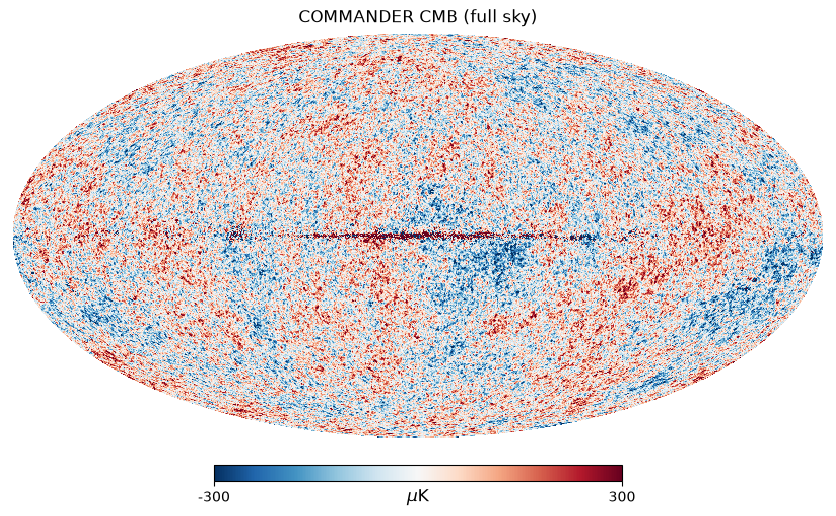

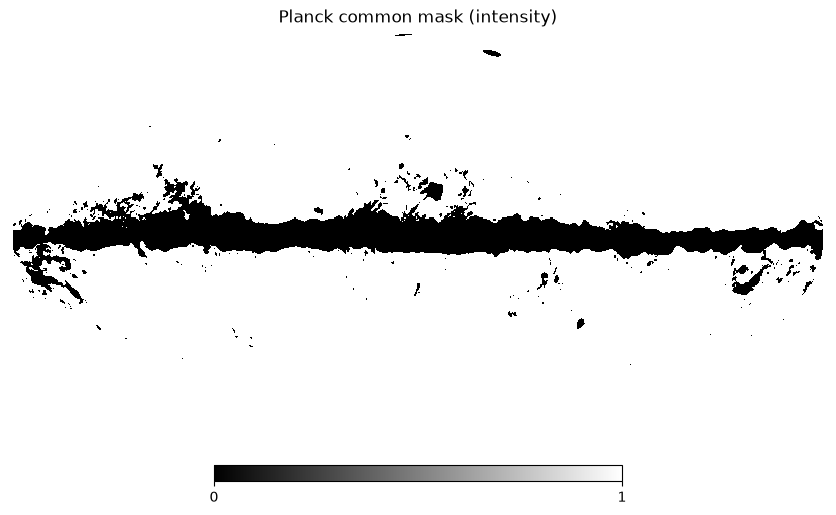

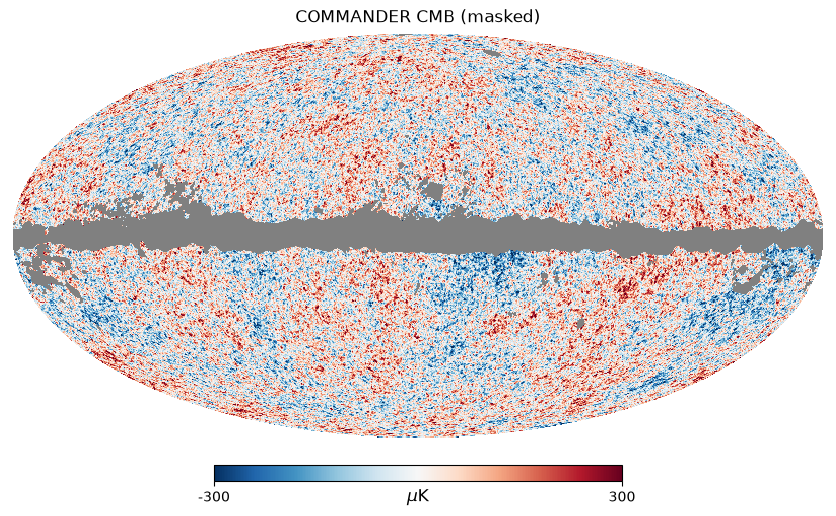

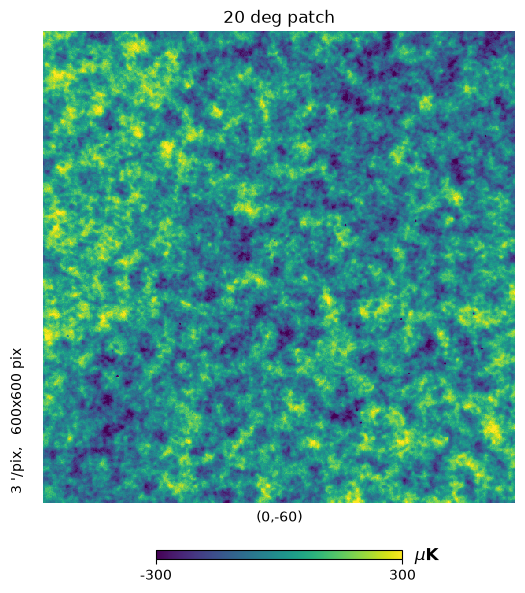

In [ ]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# ---- Load ----
cmb, mask = hp.read_map("Plancks Data/COM_CMB_IQU-commander_2048_R3.00_full.fits", field=(0, 3))

cmb *= 1e6          # K -> microK
masked = cmb * mask

# ---- Maps ----
hp.mollview(cmb, min=-300, max=300, unit=r"$\mu$K",
            title="COMMANDER CMB (full sky)", cmap="RdBu_r")
plt.savefig("Saved Data/cmb_full_sky.png", dpi=300, bbox_inches="tight")

hp.mollview(mask, title="Planck common mask (intensity)", cmap="gray")
plt.savefig("Saved Data/planck_mask.png", dpi=300, bbox_inches="tight")

masked_plot = np.where(mask > 0, masked, hp.UNSEEN) 

hp.mollview(masked_plot, min=-300, max=300, unit=r"$\mu$K",
            title="COMMANDER CMB (masked)", cmap="RdBu_r")
plt.savefig("Saved Data/cmb_masked.png", dpi=300, bbox_inches="tight")

# gnomview zoom on a patch, to see the ~1 degree hot/cold spots
hp.gnomview(masked_plot, rot=(0, -60), xsize=600, reso=3,
            min=-300, max=300, unit=r"$\mu$K", title="20 deg patch")

plt.show()


## Plotting $\ell$ vs $D_\ell$ from the masked CMB map

$b_\ell$ and $p_\ell$ are the beam and pixel window functions, respectively. 


We are using $b_\ell$ and $p_\ell$ to correct the power spectrum for the effects of the instrument's beam and the pixelization of the map. 

---
We are taking the Angular power spectrum $C_\ell$: $$C_\ell = \langle \vert{}a_{\ell m}\vert{}^2 \rangle \quad \text{(for each $\ell$)}$$
from the masked CMB map. But since $C_\ell$ falls off quickly as $\ell$ increases (plotting $C_\ell$ vs $\ell$ makes it hard to see the acoustic peaks at higher multipoles ($\ell > 200$) alongside the low-$\ell$ signal), We plot $\ell$ vs $D_\ell$ (Bandpower / Temperature Variance): $$D_\ell = \frac{\ell(\ell + 1)}{2\pi} C_\ell$$

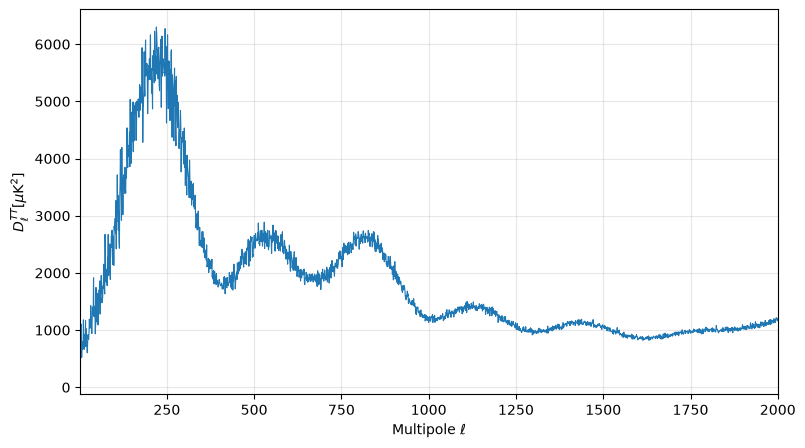

In [ ]:
# ---- Power spectrum ----
lmax = 2000
cl = hp.anafast(masked, lmax=lmax) #NOTE: anafast= analyzes a map and returns the power spectrum (C_l) up to lmax
                                   # and synfast= synthesizes a map from a given power spectrum (C_l) up to lmax

f_sky = np.mean(mask**2)
bl = hp.gauss_beam(np.radians(5/60), lmax=lmax)   # 5' beam
pl = hp.pixwin(2048)[:lmax+1]
cl = cl / (f_sky * bl**2 * pl**2) 

ell = np.arange(lmax + 1)
dl = ell * (ell + 1) * cl / (2 * np.pi)

plt.figure(figsize=(9, 5))
plt.plot(ell[2:], dl[2:], lw=0.8)
plt.xlabel(r"Multipole $\ell$")
plt.ylabel(r"$D_\ell^{TT} [\mu\mathrm{K}^2]$")
plt.xlim(2, lmax)
plt.grid(alpha=0.3)

plt.savefig("Saved Data/Angular_Power_Spectrum.png", dpi=300, bbox_inches="tight")

plt.show()

## Saving the $\ell$ vs $C_\ell$ file 

In [7]:
# Create a 2-column array: [ell, cl]
data_to_save = np.column_stack((ell, cl, dl))

# Save as a text/CSV file
np.savetxt(
    "Saved Data/APS_anafast.txt",
    data_to_save,
    header="ell Cl Dl",
    fmt=["%d", "%.18e", "%.18e"],
    comments="",)